# v1.4

## BiRNN + Attention (no skip residuals)

This notebook is a clean **attention-only counterpart** of the skip-attention version.
The data pipeline, training flow, metrics, plots, and comparison structure are kept as close as possible so we can compare:

- **BiRNN + Attention** (this file)
- **BiRNN + Skip + Attention** (`daily_birnn_skip_attention.ipynb`)

### Changelog (v1.3 -> v1.4)

- Corrected architecture documentation to match the no-skip model (removed residual/skip + LayerNorm formula/wording).
- Updated model labels in the comparison table from `BiRNN + Skip + Attn` to `BiRNN + Attn`.
- Fixed CV progress bar with `tqdm(..., total=5)` for accurate fold tracking.
- Refactored final training path: `fit()` now trains on full `X_train` instead of only the last CV fold.
- Added tail diagnostic predictions (last 20% of `X_train`) to preserve diagnostic plotting compatibility.
- Tightened Optuna learning-rate search range to `1e-4` to `1e-3` and reduced trials from `50` to `25`.
- Updated plot headings from "CV Best Fold" to "Tail Diagnostic" where applicable.
- Expanded Default/Optuna plotting from test-only to include train-set actual vs predicted curves (tail + train + test panels).

### What changed from skip-attention version

- Removed residual/skip layer behavior from recurrent stack.
- Kept bidirectional RNN + attention architecture and same evaluation workflow.
- Kept naming and structure similar for easy future A/B comparison.

### References used while preparing this version

- https://gist.github.com/ceshine/bed2dadca48fe4fe4b4600ccce2fd6e1
- https://medium.com/data-science/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66
- https://discuss.pytorch.org/t/creating-skip-connections-across-nn-modules/145408
- https://discuss.pytorch.org/t/implementing-rnn-with-short-skip-connections-in-pytorch/193893
- https://www.analyticsvidhya.com/blog/2021/08/all-you-need-to-know-about-skip-connections/
- https://github.com/OpenNMT/OpenNMT-py/blob/master/onmt/modules/stacked_rnn.py
- https://github.com/salesforce/awd-lstm-lm/blob/master/model.py
- https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/transformer.py

### Where these ideas are reflected in code

- BiRNN behavior and sequence handling: model build + recurrent stack in `BiRNNAttentionModel._build_model`.
- Attention pooling behavior: `SeqSelfAttention` usage in `BiRNNAttentionModel._build_model`.
- Comparison-ready training/evaluation structure: `cv_birnn_attention`, default/final/optuna blocks, and model comparison table.


In [2]:
!pip install keras-self-attention --quiet
!pip install optuna --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 32.9 MB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import pickle

#provided abstract class
from abc import ABC, abstractmethod

# sklearn import for tiem series cross checking
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# tensorflow import for model building
from tensorflow.keras import layers, regularizers, Input, Model, optimizers
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns
import tensorflow as tf

#hyperparameter tuning done in prev sem
import optuna

#progress bar
from tqdm.notebook import tqdm

#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

print(tf.config.list_physical_devices('GPU'))
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

Mounted at /content/drive
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs: 1


### Set random seeds

In [4]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

## Abstract Base Class

In [5]:
class BaseForecastModel(ABC):
    """
    Simple base class for forecasting models.
    """

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass

## Data Loading & Preprocessing

### Historical wheat futures prices data (1999-2025) from Investing.com

In [6]:


df1 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2018.csv')
df1['Date'] = pd.to_datetime(df1['Date'])
df1 = df1.set_index('Date', drop=True)
df1.sort_index(inplace=True)
df1['Price'] = df1['Price'].str.replace(',', '').astype('float64')
#df.to_csv('US Wheat Futures Historical Data.csv')
df1_price = df1['Price']


df2 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2025.csv')
df2['Date'] = pd.to_datetime(df2['Date'])
df2 = df2.set_index('Date', drop=True)
df2.sort_index(inplace=True)
df2['Price'] = df2['Price'].str.replace(',', '').astype('float64')
#df.to_csv('US Wheat Futures Historical Data.csv')
df2_price = df2['Price']


df = pd.concat([df1, df2.iloc[1:]])

df.to_csv('US Wheat Futures Historical Data.csv')
print("Head of merged DataFrame:")
print(df.head())
print("\nTail of merged DataFrame:")
print(df.tail())


df_price = df['Price']
df_price



Head of merged DataFrame:
             Price    Open    High     Low     Vol. Change %
Date                                                        
1999-08-01  264.75  264.00  286.75  259.00  160.06K    0.38%
1999-08-02  282.75  264.00  283.75  264.00   17.64K    6.80%
1999-08-03  272.00  282.00  286.75  271.00   14.02K   -3.80%
1999-08-04  276.50  271.25  276.75  269.00    4.98K    1.65%
1999-08-05  278.50  276.50  279.00  271.50    9.30K    0.72%

Tail of merged DataFrame:
             Price    Open    High     Low    Vol. Change %
Date                                                       
2025-12-08  534.75  535.25  540.00  532.50  49.77K   -0.19%
2025-12-09  534.50  535.50  537.75  531.25  54.30K   -0.05%
2025-12-10  529.50  534.00  535.00  525.25  68.63K   -0.94%
2025-12-11  533.50  529.75  534.75  529.25  62.42K    0.76%
2025-12-12  530.50  534.50  536.00  529.10  24.57K   -0.56%


,Price
Date,
1999-08-01,264.75
1999-08-02,282.75
1999-08-03,272.00
1999-08-04,276.50
1999-08-05,278.50
...,...
2025-12-08,534.75
2025-12-09,534.50
2025-12-10,529.50


### Macroeconomics data (1999-08 ~ 2024-12) from FRED

In [7]:
df_features = pd.read_csv('/content/drive/MyDrive/Quants /FredMD_Dataset/FRED.csv')
df_features = df_features.dropna(how='all', axis=1)
features_missing = []

for col in df_features.columns:
    if col == "Month":
        continue
    s = df_features[col].isna() | (df_features[col] == "")
    if not s.any():
        continue
    features_missing.append(col)

df_features['Month'] = pd.to_datetime(df_features['Month'])
df_features = df_features.set_index('Month').sort_index()
df_selected = df_features.drop(columns=features_missing)
features = [
    "RPI", "W875RX1", "CMRMTSPLx",
    "IPFPNSS", "USWTRADE",
    "USTRADE", "BUSLOANS", "CONSPI", "S&P 500",
    "S&P PE ratio", "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5",
    "GS10", "AAA", "BAA", "TB3SMFFM", "TB6SMFFM", "T1YFFM",
    "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx"
]

df_features = df_features[features]
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx
Month,,,,,,,,,,,,,,,,,,,,,
1999-08-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-01,3842.561807,3321.054004,434465.878601,76.647955,4924.282787,14716.772541,488.191875,0.131016,243.143463,15.946036,...,0.605389,0.765184,1.459590,2.446885,2.685952,245.311656,2.078418,1.164706,84.190164,86.923054
1999-10-01,3848.215369,3325.640164,435231.819302,76.748350,4928.615542,14733.366053,489.693146,0.130962,245.341881,15.946036,...,0.605337,0.765051,1.461043,2.447975,2.683581,245.028555,2.077490,1.165345,84.245808,86.983582
1999-11-01,7120.796970,5617.389362,435231.819302,76.878239,4932.944898,14749.936735,491.519876,0.129403,247.494265,16.060393,...,0.605796,0.765347,1.462857,2.449469,2.681144,244.744752,2.076632,1.165982,84.305102,87.031845
1999-12-01,4191.127291,4126.544304,435231.819302,76.987908,4937.331976,14766.598778,493.105573,0.129341,249.823198,16.060393,...,0.605682,0.765031,1.463829,2.450041,2.678849,244.459423,2.075703,1.166596,84.370265,87.091691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,9492.169116,8090.965184,820836.295036,71.747139,4775.909784,11914.240915,842.746761,0.135582,925.983875,19.389145,...,0.693482,1.003685,2.001372,3.001321,2.088519,193.962642,1.870707,1.197099,126.494198,85.244708
2024-09-01,9519.405260,8109.921193,822489.552603,71.782490,4777.690102,11918.954061,845.149648,0.135488,931.760812,19.422432,...,0.690546,1.000558,1.998249,2.997855,2.086957,193.902111,1.869976,1.197313,126.678704,85.217350
2024-10-01,9532.882349,8120.457541,821633.252409,71.819452,4779.453739,11923.708238,847.602589,0.135506,937.704411,19.422432,...,0.687605,0.997503,1.995146,2.994423,2.085386,193.837538,1.869281,1.197512,126.864238,85.193543


### Shift the dates of macroeconomics data by 1 month into the future, since each month's macroeconomics data is usually released in the next month and remains unknown in the current month. Then use forward-fill to transform monthly data into daily series


In [12]:
df_features = df_features.shift(periods=1, freq='infer').dropna()

#take the earliest date of the month and make it the start date.
start = df_features.index.min().replace(day=1)
#take the last date of the month and make it the end date of the month.
end = (df_features.index.max() + pd.offsets.MonthEnd(0))
#create a date range from the start to end date.
all_days = pd.date_range(start, end, freq='D')
#reindex the dataframe with the date range and  forward fill the missing values.
df_features = df_features.reindex(all_days).ffill()
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx
1999-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-09-02,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-03,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-04,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-05,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-24,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-02-25,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-02-26,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-02-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451


### Inner join wheat futures + macro data, filter post-2008.
Only use data starting in 2008 for training and testing, as financial markets generally behave differently before and after the 2008 financial crisis, leading to a structural break (this is a common practice in financial forecasting). Stale data may hurt model performances

In [13]:
df_all = df_features.join(df_price, how='inner')
df_all = df_all['2008-01-01':]
df_all

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx,Price
2008-01-01,5198.624573,4552.299829,514813.260514,63.469085,4474.762116,10775.169283,458.874403,0.131964,405.442082,17.712774,...,0.852253,1.664966,2.640887,2.473220,223.521937,2.013273,1.196308,95.685666,88.126389,929.50
2008-01-02,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,915.00
2008-01-03,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,945.00
2008-01-04,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,931.50
2008-01-07,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,903.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-24,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,593.50
2025-02-25,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,587.75
2025-02-26,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,579.75
2025-02-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,562.50


### There are 32 features in total (including wheat futures price itself), and the lookback period is 30 days before the target date. So each X sample has a rectangular shape (30 * 32). We are doing one-step-ahead forecast, so each y label is just target day's wheat futures price

In [14]:
lookback = 30

data = df_all.values
X, y = [], []
for i in range(len(data) - lookback):
    seq_x = data[i : i + lookback, :]
    target = data[i + lookback, -1]
    X.append(seq_x)
    y.append(target)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4477, 30, 32)
y shape: (4477,)


### Price plot

<Axes: >

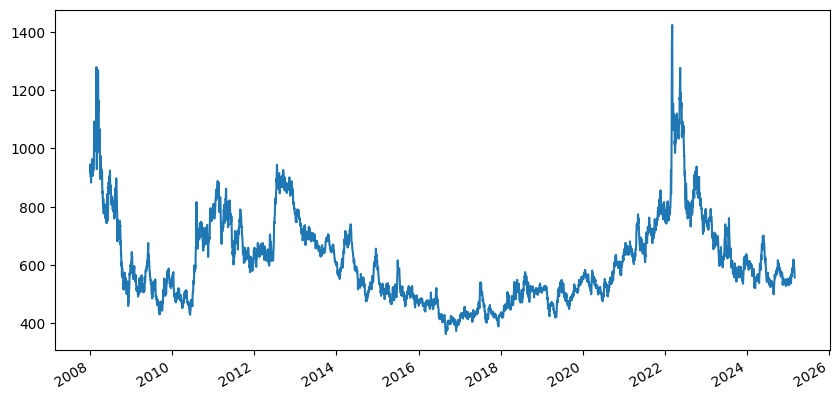

In [15]:
df_all['Price'].plot(figsize=(10, 5))

### 80/20 train-test split (no shuffling)

In [16]:
test_size = int(X.shape[0] * 0.2)

X_train = X[:-test_size]
y_train = y[:-test_size]

X_test = X[-test_size:]
y_test = y[-test_size:]

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (3582, 30, 32) (3582,)
Test set: (895, 30, 32) (895,)


### Chronological train-test split visualization

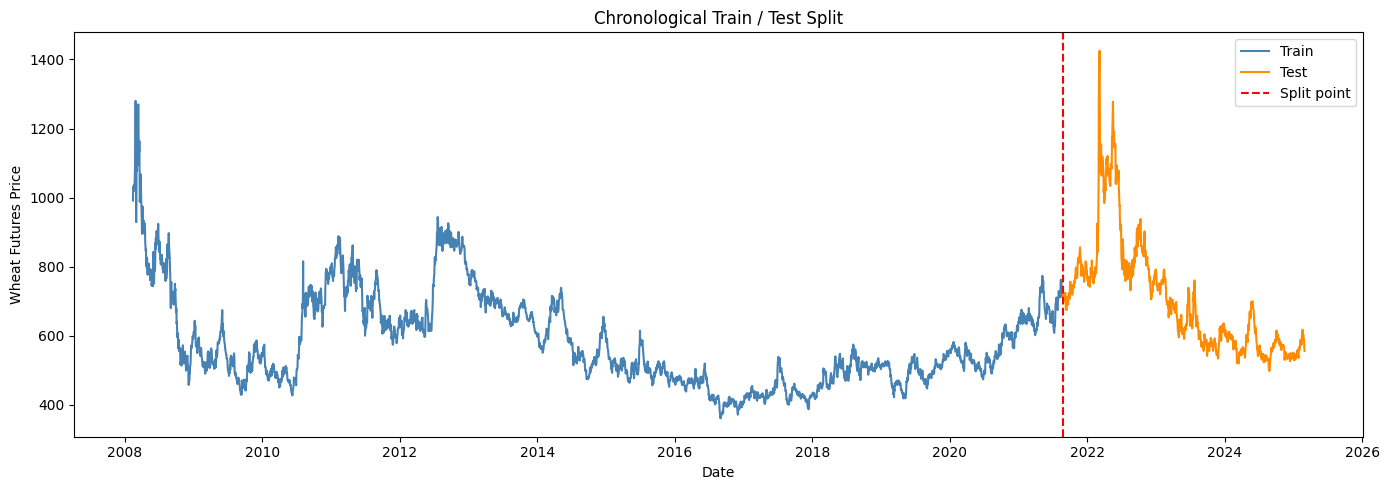

In [17]:
target_dates = df_all.index[lookback:]
train_dates = target_dates[:len(y_train)]
test_dates  = target_dates[len(y_train):]

plt.figure(figsize=(14, 5))
plt.plot(train_dates, y_train, label='Train', color='steelblue')
plt.plot(test_dates, y_test, label='Test', color='darkorange')
plt.axvline(x=train_dates[-1], color='red', linestyle='--', linewidth=1.5, label='Split point')
plt.title('Chronological Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Wheat Futures Price')
plt.legend()
plt.tight_layout()
plt.show()

## BiRNN with Attention (no skip residual layer) (implements BaseForecastModel)

Architecture:
- **Stacked BiRNN layers**: each layer is a `Bidirectional(SimpleRNN)` and passes its sequence output to the next BiRNN layer
- **No residual skip or LayerNormalization block** in this variant
- **Self-Attention**: `SeqSelfAttention` learns to weight different timesteps in the lookback window
- **Global average pooling**: collapses the attended sequence into a single vector
- **Dense head**: produces the scalar price prediction

```
Input (B, T, F)
  -> BiRNN layer 1
  -> BiRNN layer 2
  -> ...
  -> SeqSelfAttention
  -> GlobalAveragePooling1D
  -> Dropout
  -> Dense(1) -> scalar prediction
```

The `fit()` method trains the final model on full `X_train` and stores the scalers. `predict()` reuses those exact scalers — no separate scaler is ever created for the test set.

In [18]:
class BiRNNAttentionModel(BaseForecastModel):
    """
    Bidirectional SimpleRNN with attention (no residual/skip connections)
    for one-step-ahead wheat futures price forecasting.
    """

    def __init__(
        self,
        task_type: str = 'regression',
        hidden_size: int = 64,
        num_layers: int = 2,
        weight_decay: float = 0.02,
        dropout: float = 0.2,
        early_stop_patience: int = 10,
        epochs: int = 100,
        batch_size: int = 64,
        learning_rate: float = 1e-3,
    ):
        super().__init__(
            task_type=task_type,
            hidden_size=hidden_size,
            num_layers=num_layers,
            weight_decay=weight_decay,
            dropout=dropout,
            early_stop_patience=early_stop_patience,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
        )

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.weight_decay = weight_decay
        self.dropout = dropout
        self.early_stop_patience = early_stop_patience
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate

        self.model = None
        self.x_scaler = None
        self.y_scaler = None
        self.lookback = None
        self.n_features = None

        # Stored after fit() for CV Best Fold plotting
        self._cv_val_actual = None
        self._cv_val_pred = None

    def _build_model(self, seq_length: int, feature_dim: int) -> Model:
        inputs = Input(shape=(seq_length, feature_dim))

        # First BiRNN block
        h = layers.Bidirectional(
            layers.SimpleRNN(
                units=self.hidden_size,
                dropout=self.dropout,
                kernel_regularizer=regularizers.l2(self.weight_decay),
                return_sequences=True,
            )
        )(inputs)

        # Additional BiRNN blocks (no residual add)
        for _ in range(self.num_layers - 1):
            h = layers.Bidirectional(
                layers.SimpleRNN(
                    units=self.hidden_size,
                    dropout=self.dropout,
                    kernel_regularizer=regularizers.l2(self.weight_decay),
                    return_sequences=True,
                )
            )(h)

        # Attention layer
        h = SeqSelfAttention(attention_activation='sigmoid')(h)

        x = layers.GlobalAveragePooling1D()(h)
        x = layers.Dropout(self.dropout)(x)

        outputs = layers.Dense(
            units=1,
            activation='linear',
            kernel_regularizer=regularizers.l2(self.weight_decay),
        )(x)

        return Model(inputs=inputs, outputs=outputs)

    # flatten -> scale -> reshape back to 3-D.
    def _scale_X(self, X, fit: bool = False):
        n, lb, nf = X.shape
        X_flat = X.reshape(n, lb * nf)
        if fit:
            self.x_scaler = StandardScaler()
            X_flat = self.x_scaler.fit_transform(X_flat)
        else:
            X_flat = self.x_scaler.transform(X_flat)
        return X_flat.reshape(n, lb, nf)

    def fit(self, X_train, y_train):
        """
        Train final model on full X_train.

        Scalers are fitted on all training samples and reused by predict(),
        so there is no train/test scaler mismatch.

        For plotting compatibility, a tail-window diagnostic prediction
        (last 20% of X_train) is stored in _cv_val_actual / _cv_val_pred.
        """
        self.lookback = X_train.shape[1]
        self.n_features = X_train.shape[2]

        X_train_s = self._scale_X(X_train, fit=True)

        self.y_scaler = StandardScaler()
        y_train_s = self.y_scaler.fit_transform(y_train.reshape(-1, 1))

        self.model = self._build_model(self.lookback, self.n_features)
        self.model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss='mean_squared_error',
        )

        callbacks = [
            EarlyStopping(
                monitor='loss',
                patience=self.early_stop_patience,
                restore_best_weights=True,
                verbose=0,
            ),
            ReduceLROnPlateau(
                monitor='loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=0,
            ),
        ]

        self.model.fit(
            X_train_s, y_train_s,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=False,
            callbacks=callbacks,
            verbose=0,
        )

        y_train_pred = self.y_scaler.inverse_transform(
            self.model.predict(X_train_s, verbose=0).reshape(-1, 1)
        ).ravel()

        print("=== Train set performance (full X_train) ===")
        print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.6f}")
        print(f"  MAE : {mean_absolute_error(y_train, y_train_pred):.6f}")
        print(f"  R_SQUARED  : {r2_score(y_train, y_train_pred):.6f}")

        tail_n = max(1, int(len(X_train) * 0.2))
        X_tail = X_train[-tail_n:]
        y_tail = y_train[-tail_n:]
        X_tail_s = self._scale_X(X_tail, fit=False)
        y_tail_pred = self.y_scaler.inverse_transform(
            self.model.predict(X_tail_s, verbose=0).reshape(-1, 1)
        ).ravel()

        self._cv_val_actual = y_tail
        self._cv_val_pred = y_tail_pred

        print("=== Tail diagnostic performance (last 20% of X_train) ===")
        print(f"  RMSE: {np.sqrt(mean_squared_error(y_tail, y_tail_pred)):.6f}")
        print(f"  MAE : {mean_absolute_error(y_tail, y_tail_pred):.6f}")
        print(f"  R_SQUARED  : {r2_score(y_tail, y_tail_pred):.6f}")

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model not trained - call fit() first.")
        X_s = self._scale_X(X, fit=False)
        y_pred_s = self.model.predict(X_s, verbose=0)
        return self.y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

    def evaluate(self, X_test, y_test):
        preds = self.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        return {'rmse': rmse, 'mae': mae, 'r2': r2}

    def save(self, filepath: str):
        self.model.save_weights(filepath + '.weights.h5')
        meta = {
            'hyperparameters': self.hyperparameters,
            'x_scaler': self.x_scaler,
            'y_scaler': self.y_scaler,
            'lookback': self.lookback,
            'n_features': self.n_features,
            'hidden_size': self.hidden_size,
            'num_layers': self.num_layers,
        }
        with open(filepath + '.meta.pkl', 'wb') as f:
            pickle.dump(meta, f)
        print(f"Model saved to {filepath}.*")

    def load(self, filepath: str):
        with open(filepath + '.meta.pkl', 'rb') as f:
            meta = pickle.load(f)
        self.x_scaler = meta['x_scaler']
        self.y_scaler = meta['y_scaler']
        self.lookback = meta['lookback']
        self.n_features = meta['n_features']
        self.hidden_size = meta['hidden_size']
        self.num_layers = meta['num_layers']
        self.model = self._build_model(self.lookback, self.n_features)
        self.model.load_weights(filepath + '.weights.h5')
        print(f"Model loaded from {filepath}.*")



### Cross-validation function

Runs 5-fold expanding-window CV and returns a metrics dict with average RMSE, MAE, R² and val_loss across folds.

In [19]:
def cv_birnn_attention(X_train, y_train, **kwargs):
    """Run 5-fold expanding-window CV; return dict of averaged metrics."""
    tscv = TimeSeriesSplit(n_splits=5)
    lookback, n_features = X_train.shape[1], X_train.shape[2]
    fold_metrics = {'val_loss': [], 'rmse': [], 'mae': [], 'r2': []}

    for fold, (train_idx, val_idx) in tqdm(enumerate(tscv.split(X_train)), total=5):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        ns_tr, ns_val = X_tr.shape[0], X_val.shape[0]
        X_tr_flat = X_tr.reshape((ns_tr, lookback * n_features))
        X_val_flat = X_val.reshape((ns_val, lookback * n_features))

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_flat).reshape((ns_tr, lookback, n_features))
        X_val_s = scaler.transform(X_val_flat).reshape((ns_val, lookback, n_features))

        y_scaler = StandardScaler()
        y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1, 1))
        y_val_s = y_scaler.transform(y_val.reshape(-1, 1))

        tmp = BiRNNAttentionModel(**kwargs)
        model = tmp._build_model(lookback, n_features)
        model.compile(
            optimizer=Adam(learning_rate=kwargs.get('learning_rate', 1e-3)),
            loss='mean_squared_error',
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=kwargs.get('early_stop_patience', 10),
            verbose=0,
            restore_best_weights=True,
        )
        #reduce learning rate when val_loss stops improving
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0,
        )

        history = model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=kwargs.get('epochs', 100),
            batch_size=kwargs.get('batch_size', 64),
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0,
        )
        fold_metrics['val_loss'].append(min(history.history['val_loss']))

        y_val_pred = y_scaler.inverse_transform(
            model.predict(X_val_s, verbose=0).reshape(-1, 1)
        ).ravel()
        fold_metrics['rmse'].append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
        fold_metrics['mae'].append(mean_absolute_error(y_val, y_val_pred))
        fold_metrics['r2'].append(r2_score(y_val, y_val_pred))

    return {k: np.mean(v) for k, v in fold_metrics.items()}

## Default Hyperparameters — Training and Evaluation

Train the BiRNN + Attention model with **default** hyperparameters (hidden_size=64, num_layers=2, weight_decay=0.02, dropout=0.2, epochs=100, batch_size=64, lr=1e-3). Run full 5-fold CV for metrics, then train the final model on the last fold.

In [ ]:
# 5-fold CV with default hyperparameters
default_cv_metrics = cv_birnn_attention(X_train, y_train)

print("=== Default CV Metrics (avg across 5 folds) ===")
for k, v in default_cv_metrics.items():
    print(f"  {k.upper():<10}: {v:.6f}")

  0%|          | 0/5 [00:00<?, ?it/s]

=== Default CV Metrics (avg across 5 folds) ===
  VAL_LOSS  : 0.545849
  RMSE      : 58.444682
  MAE       : 48.529130
  R2        : 0.288105


In [ ]:

# Train final model with default hyperparameters
default_model = BiRNNAttentionModel()
default_model.fit(X_train, y_train)

default_test_metrics = default_model.evaluate(X_test, y_test)
print('\n=== Default — Test set performance ===')
for k, v in default_test_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

=== Train set performance (full X_train) ===
  RMSE: 35.251437
  MAE : 26.547569
  R_SQUARED  : 0.931921
=== Tail diagnostic performance (last 20% of X_train) ===
  RMSE: 21.783377
  MAE : 16.899753
  R_SQUARED  : 0.908536

=== Default — Test set performance ===
  RMSE      : 103.279869
  MAE       : 80.695481
  R2        : 0.594512


### Default — Tail Diagnostic, Train & Test plots

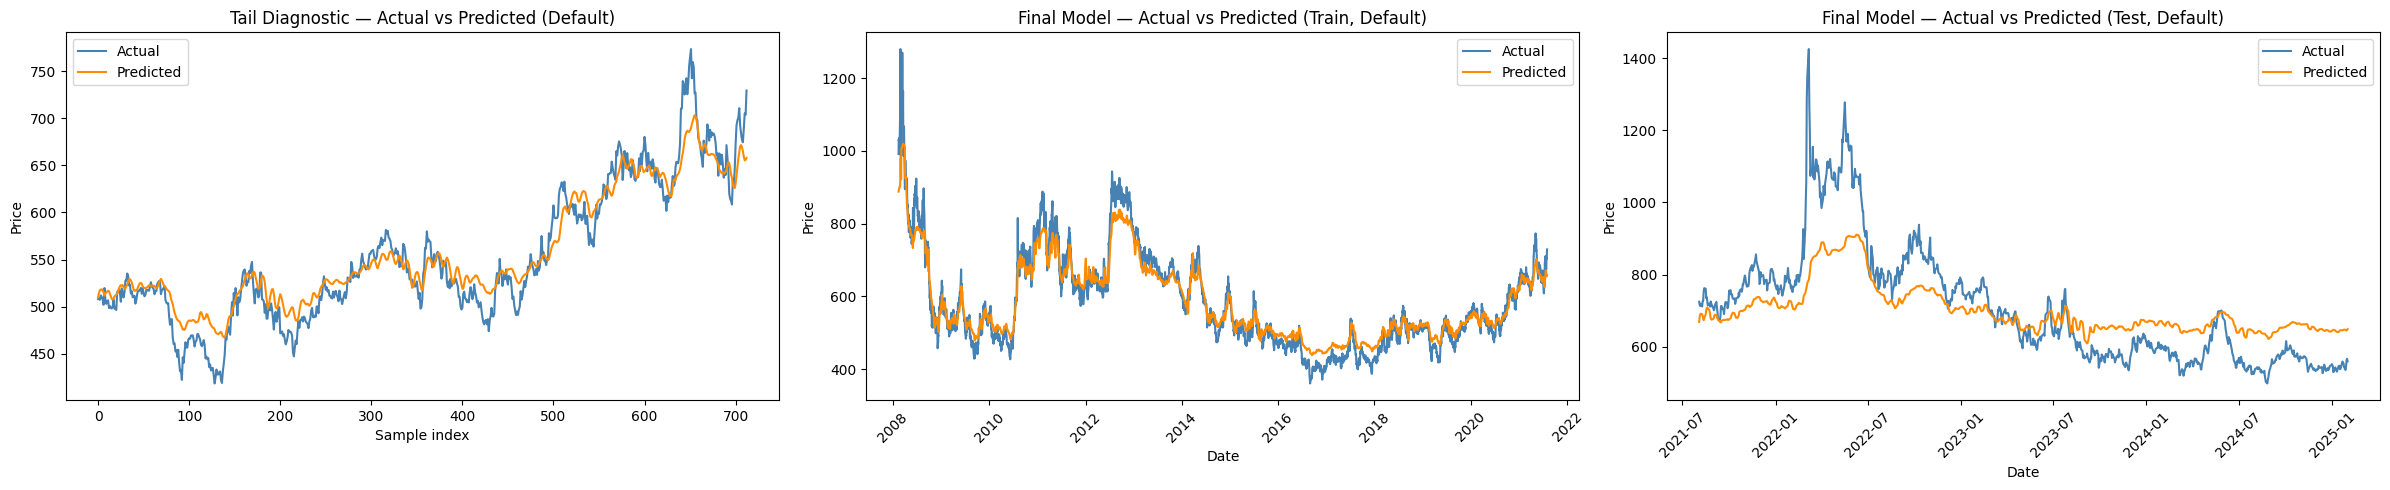

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# Tail diagnostic predictions
axes[0].plot(default_model._cv_val_actual, label='Actual', color='steelblue')
axes[0].plot(default_model._cv_val_pred, label='Predicted', color='darkorange')
axes[0].set_title('Tail Diagnostic — Actual vs Predicted (Default)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Price')
axes[0].legend()

# Train predictions
train_dates = df_all.index[lookback:lookback + len(y_train)]
default_train_preds = default_model.predict(X_train)

axes[1].plot(train_dates, y_train, label='Actual', color='steelblue')
axes[1].plot(train_dates, default_train_preds, label='Predicted', color='darkorange')
axes[1].set_title('Final Model — Actual vs Predicted (Train, Default)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Test predictions
test_dates = df_all.index[-len(X_test):]
default_test_preds = default_model.predict(X_test)

axes[2].plot(test_dates, y_test, label='Actual', color='steelblue')
axes[2].plot(test_dates, default_test_preds, label='Predicted', color='darkorange')
axes[2].set_title('Final Model — Actual vs Predicted (Test, Default)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

## Optuna Hyperparameter Search (BiRNN + Attention)

Hyperparameters tuned: hidden_size, num_layers, weight_decay, dropout, early_stop_patience, epochs, batch_size, and learning_rate.

In [ ]:
def objective(trial):
    params = dict(
        hidden_size=trial.suggest_categorical('hidden_size', [32, 64, 128]),
        num_layers=trial.suggest_categorical('num_layers', [1, 2, 3]),
        weight_decay=trial.suggest_float('weight_decay', 5e-4, 2e-2, log=True),
        dropout=trial.suggest_float('dropout', 0.1, 0.3),
        early_stop_patience=trial.suggest_int('early_stop_patience', 10, 15),
        epochs=trial.suggest_int('epochs', 50, 200),
        batch_size=trial.suggest_categorical('batch_size', [32, 64]),
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
    )
    result = cv_birnn_attention(X_train, y_train, **params)
    trial.set_user_attr('cv_metrics', result)
    return result['val_loss']


N_TRIALS = 25
study = optuna.create_study(direction='minimize')
progress_bar = tqdm(total=N_TRIALS, desc='Optuna trials')
study.optimize(objective, n_trials=N_TRIALS, callbacks=[lambda study, trial: progress_bar.update(1)])
progress_bar.close()

print('\nBest CV score (val_loss):', study.best_value)
print('Best hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

optuna_cv_metrics = study.best_trial.user_attrs['cv_metrics']
print('\n=== Optuna CV Metrics (avg across 5 folds) ===')
for k, v in optuna_cv_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

[I 2026-02-22 13:52:49,853] A new study created in memory with name: no-name-c3b7e33c-3111-4956-80de-50a457673aa7


Optuna trials:   0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 13:55:20,319] Trial 0 finished with value: 0.7178212344646454 and parameters: {'hidden_size': 64, 'num_layers': 1, 'weight_decay': 0.004773775087921569, 'dropout': 0.13755060075224584, 'early_stop_patience': 12, 'epochs': 131, 'batch_size': 32, 'learning_rate': 0.0003017107772106665}. Best is trial 0 with value: 0.7178212344646454.


  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 14:57:36,931] Trial 23 finished with value: 0.23685374855995178 and parameters: {'hidden_size': 128, 'num_layers': 1, 'weight_decay': 0.0006960019540528043, 'dropout': 0.14873084010496773, 'early_stop_patience': 14, 'epochs': 51, 'batch_size': 64, 'learning_rate': 0.0007498531369488389}. Best is trial 1 with value: 0.21085498332977295.


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 14:59:26,706] Trial 24 finished with value: 0.19806584268808364 and parameters: {'hidden_size': 128, 'num_layers': 1, 'weight_decay': 0.0005017752361510938, 'dropout': 0.14709605693443337, 'early_stop_patience': 14, 'epochs': 51, 'batch_size': 64, 'learning_rate': 0.0006959990978522112}. Best is trial 24 with value: 0.19806584268808364.



Best CV score (val_loss): 0.19806584268808364
Best hyperparameters:
  hidden_size: 128
  num_layers: 1
  weight_decay: 0.0005017752361510938
  dropout: 0.14709605693443337
  early_stop_patience: 14
  epochs: 51
  batch_size: 64
  learning_rate: 0.0006959990978522112

=== Optuna CV Metrics (avg across 5 folds) ===
  VAL_LOSS  : 0.198066
  RMSE      : 51.755600
  MAE       : 41.892706
  R2        : 0.491371


## Train, Evaluate & Plot (BiRNN + Attention with Optuna best hyperparameters)

In [ ]:
best_params = study.best_params

optuna_model = BiRNNAttentionModel(
    task_type='regression',
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    weight_decay=best_params['weight_decay'],
    dropout=best_params['dropout'],
    early_stop_patience=best_params['early_stop_patience'],
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    learning_rate=best_params['learning_rate'],
)

optuna_model.fit(X_train, y_train)

optuna_test_metrics = optuna_model.evaluate(X_test, y_test)
print('\n=== Optuna — Test set performance ===')
for k, v in optuna_test_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

=== Train set performance (full X_train) ===
  RMSE: 34.897645
  MAE : 25.385116
  R_SQUARED  : 0.933280
=== Tail diagnostic performance (last 20% of X_train) ===
  RMSE: 27.600321
  MAE : 20.530936
  R_SQUARED  : 0.853165

=== Optuna — Test set performance ===
  RMSE      : 74.731993
  MAE       : 55.348699
  R2        : 0.787695


### Optuna — Tail Diagnostic, Train & Test plots

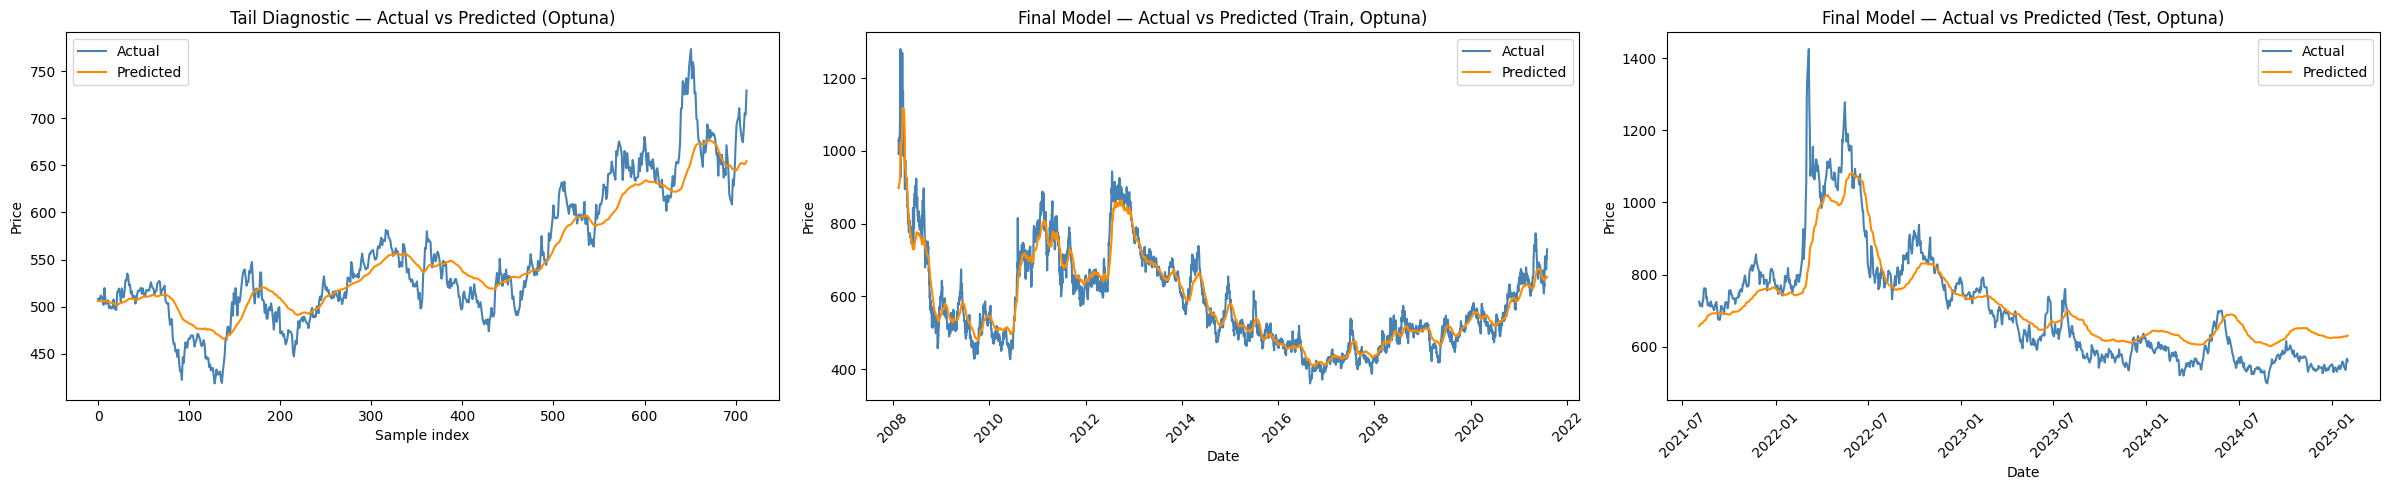

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# Tail diagnostic predictions
axes[0].plot(optuna_model._cv_val_actual, label='Actual', color='steelblue')
axes[0].plot(optuna_model._cv_val_pred, label='Predicted', color='darkorange')
axes[0].set_title('Tail Diagnostic — Actual vs Predicted (Optuna)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Price')
axes[0].legend()

# Train predictions
train_dates = df_all.index[lookback:lookback + len(y_train)]
optuna_train_preds = optuna_model.predict(X_train)

axes[1].plot(train_dates, y_train, label='Actual', color='steelblue')
axes[1].plot(train_dates, optuna_train_preds, label='Predicted', color='darkorange')
axes[1].set_title('Final Model — Actual vs Predicted (Train, Optuna)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Test predictions
test_dates = df_all.index[-len(X_test):]
optuna_test_preds = optuna_model.predict(X_test)

axes[2].plot(test_dates, y_test, label='Actual', color='steelblue')
axes[2].plot(test_dates, optuna_test_preds, label='Predicted', color='darkorange')
axes[2].set_title('Final Model — Actual vs Predicted (Test, Optuna)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

## Naive Baseline

Each day's price prediction equals the previous day's price.

In [ ]:
last_train_price = y_train[-1]
naive_preds = np.empty(len(y_test))
naive_preds[0] = last_train_price
naive_preds[1:] = y_test[:-1]

naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_r2 = r2_score(y_test, naive_preds)

print('=== Naive One-Day-Ahead Forecast ===')
print(f'RMSE: {naive_rmse:.6f}')
print(f'R_SQUARED  : {naive_r2:.6f}')
print(f'MAE : {naive_mae:.6f}')

=== Naive One-Day-Ahead Forecast ===
RMSE: 20.370589
R_SQUARED  : 0.984226
MAE : 12.850842


## Model Comparison

In [ ]:
comparison = pd.DataFrame([
    {
        'Model': 'Naive',
        'RMSE': naive_rmse,
        'MAE': naive_mae,
        'R_SQUARED': naive_r2,
    },
    {
        'Model': 'BiRNN + Attn (Default CV)',
        'RMSE': default_cv_metrics['rmse'],
        'MAE': default_cv_metrics['mae'],
        'R_SQUARED': default_cv_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Attn (Default Final)',
        'RMSE': default_test_metrics['rmse'],
        'MAE': default_test_metrics['mae'],
        'R_SQUARED': default_test_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Attn (Optuna CV)',
        'RMSE': optuna_cv_metrics['rmse'],
        'MAE': optuna_cv_metrics['mae'],
        'R_SQUARED': optuna_cv_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Attn (Optuna Final)',
        'RMSE': optuna_test_metrics['rmse'],
        'MAE': optuna_test_metrics['mae'],
        'R_SQUARED': optuna_test_metrics['r2'],
    },
])

comparison = comparison.set_index('Model')

comparison.style \
    .highlight_min(subset=['RMSE', 'MAE'], color='#d4edda') \
    .highlight_max(subset=['R_SQUARED'], color='#d4edda') \
    .format('{:.6f}')

,RMSE,MAE,R_SQUARED
Model,,,
Naive,20.370589,12.850842,0.984226
BiRNN + Attn (Default CV),58.444682,48.529130,0.288105
BiRNN + Attn (Default Final),103.279869,80.695481,0.594512
BiRNN + Attn (Optuna CV),51.755600,41.892706,0.491371
BiRNN + Attn (Optuna Final),74.731993,55.348699,0.787695


## Save & Load

In [ ]:
optuna_model.save('birnn_attention_wheat')

loaded = BiRNNAttentionModel()
loaded.load('birnn_attention_wheat')

loaded_metrics = loaded.evaluate(X_test, y_test)
print('\nLoaded model test metrics:')
for name, value in loaded_metrics.items():
    print(f'  {name.upper()}: {value:.6f}')

print(f"\nPredictions match: {np.allclose(optuna_model.predict(X_test), loaded.predict(X_test))}")

Model saved to birnn_attention_wheat.*
Model loaded from birnn_attention_wheat.*

Loaded model test metrics:
  RMSE: 74.731993
  MAE: 55.348699
  R2: 0.787695

Predictions match: True


---

# Part 2: Binary Classification Extension

## BiRNN + Attn Classifier — Predicting Price Direction (Up / Down)

This section reuses the same RNN backbone from the regression task above but
adapts it for **binary classification** (next-day price goes up vs down).

**Key improvements over naive level-based classification:**

1. **Returns-based features** — all input features are transformed to daily
   percentage changes (`pct_change`), making the data more stationary and
   removing price-level non-stationarity that causes the classifier to collapse.
2. **Technical indicators** — Moving Averages, MACD, Bollinger Bands, RSI, and
   Momentum are computed from the price series and added as extra features.
3. **Class weighting** — `class_weight` in `model.fit` counteracts any class
   imbalance so the model does not default to predicting the majority class.
4. **Threshold optimisation** — instead of a fixed 0.5 cutoff, the optimal
   classification threshold is selected on the validation fold.
5. **Economic gain evaluation** — simulated trading P&L measures the real-world
   value of the predictions.

In [21]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

### Feature engineering for classification

We start from `df_all` (the merged FRED-MD + Price dataframe used in Part 1)
and build a **returns-based** feature set enriched with technical indicators.
This is fundamentally different from the regression pipeline which uses raw
price levels.

In [22]:
# ── Feature engineering for classification ──────────────────────────────────

df_cls = df_all.copy()

# --- Technical indicators (computed on raw Price before taking returns) ---
price = df_cls['Price']

# Moving averages
df_cls['MA_5']  = price.rolling(window=5).mean()
df_cls['MA_10'] = price.rolling(window=10).mean()
df_cls['MA_20'] = price.rolling(window=20).mean()

# MACD (12-day EMA minus 26-day EMA) and signal line
ema12 = price.ewm(span=12, adjust=False).mean()
ema26 = price.ewm(span=26, adjust=False).mean()
df_cls['MACD']        = ema12 - ema26
df_cls['MACD_signal'] = df_cls['MACD'].ewm(span=9, adjust=False).mean()

# Bollinger Bands (20-day)
bb_ma = price.rolling(window=20).mean()
bb_sd = price.rolling(window=20).std()
df_cls['BB_upper'] = bb_ma + 2 * bb_sd
df_cls['BB_lower'] = bb_ma - 2 * bb_sd
df_cls['BB_width'] = df_cls['BB_upper'] - df_cls['BB_lower']

# RSI (14-day)
delta = price.diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs    = gain / loss.replace(0, np.finfo(float).eps)
df_cls['RSI'] = 100 - (100 / (1 + rs))

# Momentum
df_cls['Momentum_5']  = price.pct_change(5)
df_cls['Momentum_10'] = price.pct_change(10)

# --- Convert ALL columns to daily percentage changes ---
df_returns = df_cls.pct_change()

# Drop the first rows that are NaN from pct_change / rolling windows
df_returns = df_returns.dropna()

# Replace any remaining inf values with 0
df_returns = df_returns.replace([np.inf, -np.inf], 0)

print(f'Returns-based feature matrix: {df_returns.shape}')
print(f'Features ({df_returns.shape[1]}): {list(df_returns.columns)}')
df_returns.head()

Returns-based feature matrix: (4487, 43)
Features (43): ['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'Price', 'MA_5', 'MA_10', 'MA_20', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 'BB_width', 'RSI', 'Momentum_5', 'Momentum_10']


,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,MA_10,MA_20,MACD,MACD_signal,BB_upper,BB_lower,BB_width,RSI,Momentum_5,Momentum_10
2008-01-30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,-0.001016,-0.000379,-0.266012,0.614925,-0.000439,-0.000312,-0.001720,-0.013780,0.806077,-1.346189
2008-01-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000321,0.000785,-0.105570,0.251348,0.000624,0.000962,-0.002788,0.048780,0.166274,-1.317664
2008-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000268,-0.000108,0.305322,0.270816,-0.000302,0.000104,-0.004423,-0.037849,-0.524743,-0.179071
2008-02-04,0.001563,0.001477,0.001531,0.001349,0.000593,0.000723,0.003606,0.000003,0.004477,0.0,...,0.001124,0.002245,0.868485,0.492242,0.007470,-0.003492,0.119321,0.063797,-0.031153,3.104000
2008-02-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.007375,0.005398,0.725596,0.600494,0.014966,-0.005224,0.198374,0.035013,5.018750,5.771949


### Classification windows and target labels

We construct lookback windows from the returns-based features.
The target is binary: **1** if the next-day price return is positive (price goes up),
**0** otherwise. The `Price` column in `df_returns` already represents daily returns,
so `y_cls[i] = 1` iff the return on day `i + lookback` is positive.

In [23]:
# ── Classification windows ─────────────────────────────────────────────────

lookback_cls = 30

data_cls = df_returns.values
price_col_idx = list(df_returns.columns).index('Price')

X_cls, y_cls = [], []
for i in range(len(data_cls) - lookback_cls):
    seq_x = data_cls[i : i + lookback_cls, :]
    next_return = data_cls[i + lookback_cls, price_col_idx]
    X_cls.append(seq_x)
    y_cls.append(1 if next_return > 0 else 0)

X_cls = np.array(X_cls)
y_cls = np.array(y_cls)

print(f'X_cls shape: {X_cls.shape}')
print(f'y_cls shape: {y_cls.shape}')

# 80/20 chronological split
test_size_cls = int(X_cls.shape[0] * 0.2)

X_train_cls = X_cls[:-test_size_cls]
y_train_cls = y_cls[:-test_size_cls]
X_test_cls  = X_cls[-test_size_cls:]
y_test_cls  = y_cls[-test_size_cls:]

print(f'\nTrain: {len(y_train_cls)} samples | up={y_train_cls.sum()} ({y_train_cls.mean():.2%}), down={len(y_train_cls) - y_train_cls.sum()} ({1 - y_train_cls.mean():.2%})')
print(f'Test : {len(y_test_cls)} samples  | up={y_test_cls.sum()} ({y_test_cls.mean():.2%}), down={len(y_test_cls) - y_test_cls.sum()} ({1 - y_test_cls.mean():.2%})')

X_cls shape: (4457, 30, 43)
y_cls shape: (4457,)

Train: 3566 samples | up=1697 (47.59%), down=1869 (52.41%)
Test : 891 samples  | up=419 (47.03%), down=472 (52.97%)


### Class weights

Compute class weights inversely proportional to class frequency so the
model does not collapse to predicting only the majority class.

In [24]:
from sklearn.utils.class_weight import compute_class_weight

cw_vals = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_cls)
class_weights = {0: cw_vals[0], 1: cw_vals[1]}
print(f'Class weights: {class_weights}')

Class weights: {0: np.float64(0.9539860888175495), 1: np.float64(1.0506776664702415)}


### BiRNN + Attn Classifier

Same backbone architecture as the regression model above, adapted for
binary classification:
- Output activation: `sigmoid`
- Loss: `binary_crossentropy`
- `class_weight` passed to `model.fit` to handle imbalance
- `predict()` returns probabilities; `predict_classes(threshold)` returns hard labels
- `evaluate()` returns accuracy, precision, recall, F1, and AUC-ROC

In [25]:
class BiRNNAttentionClassifier(BaseForecastModel):
    """
    Binary classifier variant — BiRNN + Attn backbone.
    Sigmoid output + binary cross-entropy. Supports class_weight.
    """

    def __init__(
        self,
        task_type: str = 'classification',
        hidden_size: int = 64,
        num_layers: int = 2,
        weight_decay: float = 0.02,
        dropout: float = 0.2,
        early_stop_patience: int = 10,
        epochs: int = 100,
        batch_size: int = 64,
        learning_rate: float = 1e-3,
    ):
        super().__init__(
            task_type=task_type,
            hidden_size=hidden_size,
            num_layers=num_layers,
            weight_decay=weight_decay,
            dropout=dropout,
            early_stop_patience=early_stop_patience,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
        )

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.weight_decay = weight_decay
        self.dropout = dropout
        self.early_stop_patience = early_stop_patience
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate

        self.model = None
        self.x_scaler = None
        self.lookback = None
        self.n_features = None

        self._cv_val_actual = None
        self._cv_val_pred = None
        self._cv_val_prob = None
        self._train_actual = None
        self._train_pred = None
        self._train_prob = None

    def _scale_X(self, X, fit: bool = False):
        n, lb, nf = X.shape
        X_flat = X.reshape(n, lb * nf)
        if fit:
            self.x_scaler = StandardScaler()
            X_flat = self.x_scaler.fit_transform(X_flat)
        else:
            X_flat = self.x_scaler.transform(X_flat)
        return X_flat.reshape(n, lb, nf)

    def _build_model(self, seq_length: int, feature_dim: int) -> Model:
        inputs = Input(shape=(seq_length, feature_dim))

        h = layers.Bidirectional(
            layers.SimpleRNN(
                units=self.hidden_size,
                dropout=self.dropout,
                kernel_regularizer=regularizers.l2(self.weight_decay),
                return_sequences=True,
            )
        )(inputs)

        for _ in range(self.num_layers - 1):
            h = layers.Bidirectional(
                layers.SimpleRNN(
                    units=self.hidden_size,
                    dropout=self.dropout,
                    kernel_regularizer=regularizers.l2(self.weight_decay),
                    return_sequences=True,
                )
            )(h)

        h = SeqSelfAttention(attention_activation='sigmoid')(h)

        x = layers.GlobalAveragePooling1D()(h)
        x = layers.Dropout(self.dropout)(x)

        outputs = layers.Dense(
            units=1,
            activation='sigmoid',
            kernel_regularizer=regularizers.l2(self.weight_decay),
        )(x)

        return Model(inputs=inputs, outputs=outputs)

    def fit(self, X_train, y_train, class_weight=None):
        self.lookback = X_train.shape[1]
        self.n_features = X_train.shape[2]
        X_scaled = self._scale_X(X_train, fit=True)

        self.model = self._build_model(self.lookback, self.n_features)
        self.model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy'],
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=self.early_stop_patience,
            mode='min',
            verbose=0,
            restore_best_weights=True,
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0,
        )

        self.model.fit(
            X_scaled, y_train,
            validation_split=0.15,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            class_weight=class_weight,
            verbose=0,
        )

        train_probs = self.model.predict(X_scaled, verbose=0).ravel()
        self._train_prob = train_probs
        self._train_pred = (train_probs >= 0.5).astype(int)
        self._train_actual = y_train
        return self

    def predict(self, X):
        X_scaled = self._scale_X(X, fit=False)
        return self.model.predict(X_scaled, verbose=0).ravel()

    def predict_classes(self, X, threshold=0.5):
        return (self.predict(X) >= threshold).astype(int)

    def evaluate(self, X_test, y_test, threshold=0.5):
        probs = self.predict(X_test)
        preds = (probs >= threshold).astype(int)
        return {
            'accuracy':  accuracy_score(y_test, preds),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall':    recall_score(y_test, preds, zero_division=0),
            'f1':        f1_score(y_test, preds, zero_division=0),
            'auc_roc':   roc_auc_score(y_test, probs),
        }

    def save(self, filepath: str):
        self.model.save(f'{filepath}_model.keras')
        meta = {
            'x_scaler': self.x_scaler,
            'lookback': self.lookback,
            'n_features': self.n_features,
            'hyperparameters': {
                'hidden_size': self.hidden_size,
                'num_layers': self.num_layers,
                'weight_decay': self.weight_decay,
                'dropout': self.dropout,
                'early_stop_patience': self.early_stop_patience,
                'epochs': self.epochs,
                'batch_size': self.batch_size,
                'learning_rate': self.learning_rate,
            },
        }
        with open(f'{filepath}_meta.pkl', 'wb') as f:
            pickle.dump(meta, f)

    def load(self, filepath: str):
        self.model = tf.keras.models.load_model(f'{filepath}_model.keras')
        with open(f'{filepath}_meta.pkl', 'rb') as f:
            meta = pickle.load(f)
        self.x_scaler = meta['x_scaler']
        self.lookback = meta['lookback']
        self.n_features = meta['n_features']
        hp = meta['hyperparameters']
        for k, v in hp.items():
            setattr(self, k, v)

### Cross-validation function (classification)

5-fold expanding-window time-series CV.
Tracks classification metrics **and** finds the best probability threshold
per fold (maximising F1 on validation).

In [26]:
def cv_birnn_attention_cls(X_train, y_train_cls, class_weight=None, **kwargs):
    """5-fold expanding-window CV for classification; returns averaged metrics + best threshold."""
    tscv = TimeSeriesSplit(n_splits=5)
    lookback, n_features = X_train.shape[1], X_train.shape[2]
    fold_metrics = {'val_loss': [], 'accuracy': [], 'f1': [], 'auc_roc': [], 'best_threshold': []}

    for fold, (train_idx, val_idx) in tqdm(enumerate(tscv.split(X_train)), total=5):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train_cls[train_idx], y_train_cls[val_idx]

        ns_tr, ns_val = X_tr.shape[0], X_val.shape[0]
        X_tr_flat = X_tr.reshape((ns_tr, lookback * n_features))
        X_val_flat = X_val.reshape((ns_val, lookback * n_features))

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_flat).reshape((ns_tr, lookback, n_features))
        X_val_s = scaler.transform(X_val_flat).reshape((ns_val, lookback, n_features))

        tmp = BiRNNAttentionClassifier(**kwargs)
        model = tmp._build_model(lookback, n_features)
        model.compile(
            optimizer=Adam(learning_rate=kwargs.get('learning_rate', 1e-3)),
            loss='binary_crossentropy',
            metrics=['accuracy'],
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=kwargs.get('early_stop_patience', 10),
            mode='min',
            verbose=0,
            restore_best_weights=True,
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0,
        )

        history = model.fit(
            X_tr_s, y_tr,
            validation_data=(X_val_s, y_val),
            epochs=kwargs.get('epochs', 100),
            batch_size=kwargs.get('batch_size', 64),
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            class_weight=class_weight,
            verbose=0,
        )
        fold_metrics['val_loss'].append(min(history.history['val_loss']))

        val_probs = model.predict(X_val_s, verbose=0).ravel()

        # Find threshold that maximises F1 on this fold
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.30, 0.71, 0.01):
            preds_t = (val_probs >= t).astype(int)
            f1_t = f1_score(y_val, preds_t, zero_division=0)
            if f1_t > best_f1:
                best_f1 = f1_t
                best_t = t
        fold_metrics['best_threshold'].append(best_t)

        val_preds = (val_probs >= best_t).astype(int)
        fold_metrics['accuracy'].append(accuracy_score(y_val, val_preds))
        fold_metrics['f1'].append(f1_score(y_val, val_preds, zero_division=0))
        try:
            fold_metrics['auc_roc'].append(roc_auc_score(y_val, val_probs))
        except ValueError:
            fold_metrics['auc_roc'].append(0.5)

        tf.keras.backend.clear_session()

    return {k: float(np.mean(v)) for k, v in fold_metrics.items()}

### Default hyperparameters — Classification

Train the BiRNN + Attn classifier with default hyperparameters and class
weights. We first run 5-fold CV to get averaged metrics, then train the final
model on full training data.

In [27]:
default_cls_cv_metrics = cv_birnn_attention_cls(X_train_cls, y_train_cls, class_weight=class_weights)
print("\n=== Default CV Classification Metrics (5-fold avg) ===")
for k, v in default_cls_cv_metrics.items():
    print(f"  {k}: {v:.6f}")

  0%|          | 0/5 [00:00<?, ?it/s]


=== Default CV Classification Metrics (5-fold avg) ===
  val_loss: 0.716801
  accuracy: 0.480808
  f1: 0.646630
  auc_roc: 0.525680
  best_threshold: 0.300000


In [28]:
default_cls_model = BiRNNAttentionClassifier()
default_cls_model.fit(X_train_cls, y_train_cls, class_weight=class_weights)

best_threshold_default = default_cls_cv_metrics['best_threshold']
print(f'Using optimised threshold: {best_threshold_default:.2f}')

default_cls_test = default_cls_model.evaluate(X_test_cls, y_test_cls, threshold=best_threshold_default)
print("\n=== Default Test Classification Metrics ===")
for k, v in default_cls_test.items():
    print(f"  {k.upper()}: {v:.6f}")

Using optimised threshold: 0.30

=== Default Test Classification Metrics ===
  ACCURACY: 0.470258
  PRECISION: 0.470258
  RECALL: 1.000000
  F1: 0.639695
  AUC_ROC: 0.515109


### Default — Confusion Matrix, ROC Curve & Classification Report

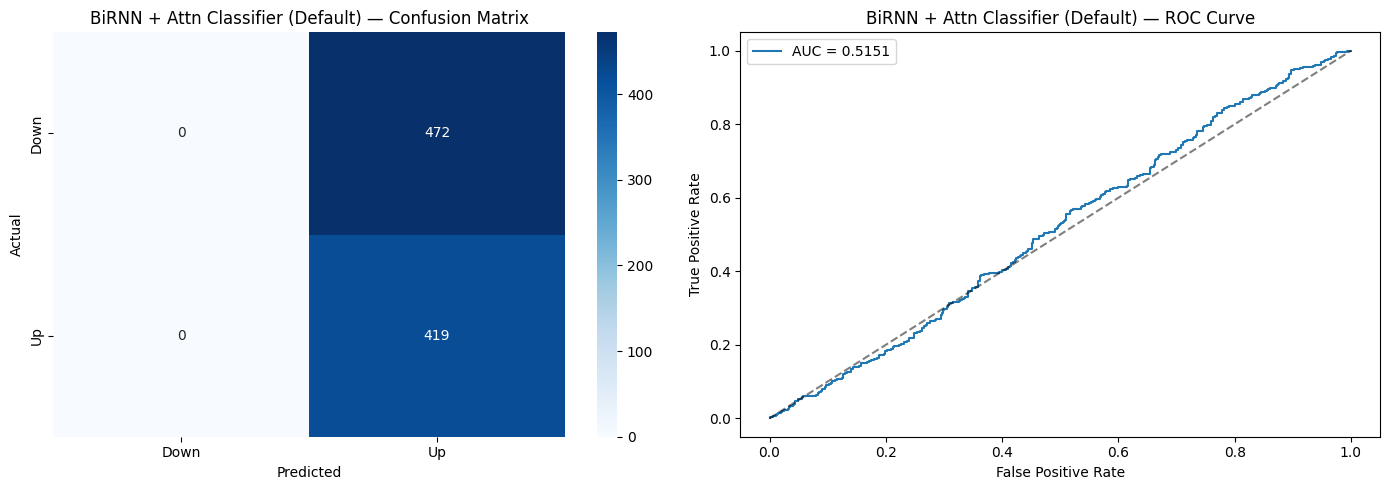


Classification Report (Default):
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       472
          Up       0.47      1.00      0.64       419

    accuracy                           0.47       891
   macro avg       0.24      0.50      0.32       891
weighted avg       0.22      0.47      0.30       891



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
test_probs_default = default_cls_model.predict(X_test_cls)
test_preds_default = (test_probs_default >= best_threshold_default).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_cls, test_preds_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('BiRNN + Attn Classifier (Default) — Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test_cls, test_probs_default)
axes[1].plot(fpr, tpr, label=f'AUC = {default_cls_test["auc_roc"]:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('BiRNN + Attn Classifier (Default) — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nClassification Report (Default):")
print(classification_report(y_test_cls, test_preds_default, target_names=['Down', 'Up']))

### Optuna hyperparameter tuning — Classification

Same search space as regression. Objective minimises mean CV `val_loss`
(binary cross-entropy). Class weights are passed through.

In [30]:
def objective_cls(trial):
    params = dict(
        hidden_size=trial.suggest_categorical('hidden_size', [32, 64, 128]),
        num_layers=trial.suggest_categorical('num_layers', [1, 2, 3]),
        weight_decay=trial.suggest_float('weight_decay', 1e-4, 1e-1, log=True),
        dropout=trial.suggest_float('dropout', 0.1, 0.3),
        early_stop_patience=trial.suggest_int('early_stop_patience', 10, 15),
        epochs=trial.suggest_int('epochs', 50, 200),
        batch_size=trial.suggest_categorical('batch_size', [32, 64]),
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
    )
    result = cv_birnn_attention_cls(X_train_cls, y_train_cls, class_weight=class_weights, **params)
    return result['val_loss']

N_TRIALS_CLS = 2
study_cls = optuna.create_study(direction='minimize')
progress_bar_cls = tqdm(total=N_TRIALS_CLS, desc='Optuna CLS trials')
study_cls.optimize(objective_cls, n_trials=N_TRIALS_CLS,
                   callbacks=[lambda study, trial: progress_bar_cls.update(1)])
progress_bar_cls.close()

print('\nBest CV score (val_loss):', study_cls.best_value)
print('Best params:', study_cls.best_params)

[I 2026-03-11 18:00:35,653] A new study created in memory with name: no-name-ae6a91d7-760c-4e6d-a48d-766da8ce31b0


Optuna CLS trials:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-03-11 18:04:56,556] Trial 0 finished with value: 1.0193880438804626 and parameters: {'hidden_size': 128, 'num_layers': 2, 'weight_decay': 0.0021338284180915617, 'dropout': 0.17464007890882952, 'early_stop_patience': 14, 'epochs': 128, 'batch_size': 64, 'learning_rate': 0.00019354021161464683}. Best is trial 0 with value: 1.0193880438804626.


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-03-11 18:07:21,983] Trial 1 finished with value: 0.7226436018943787 and parameters: {'hidden_size': 32, 'num_layers': 1, 'weight_decay': 0.002504865068776861, 'dropout': 0.2560778902634743, 'early_stop_patience': 15, 'epochs': 200, 'batch_size': 64, 'learning_rate': 0.0006084409760182862}. Best is trial 1 with value: 0.7226436018943787.



Best CV score (val_loss): 0.7226436018943787
Best params: {'hidden_size': 32, 'num_layers': 1, 'weight_decay': 0.002504865068776861, 'dropout': 0.2560778902634743, 'early_stop_patience': 15, 'epochs': 200, 'batch_size': 64, 'learning_rate': 0.0006084409760182862}


### Train final classifier with Optuna best hyperparameters

In [31]:
optuna_cls_cv_metrics = cv_birnn_attention_cls(X_train_cls, y_train_cls, class_weight=class_weights, **study_cls.best_params)
print("\n=== Optuna CV Classification Metrics (5-fold avg) ===")
for k, v in optuna_cls_cv_metrics.items():
    print(f"  {k}: {v:.6f}")

  0%|          | 0/5 [00:00<?, ?it/s]


=== Optuna CV Classification Metrics (5-fold avg) ===
  val_loss: 0.721561
  accuracy: 0.486532
  f1: 0.647593
  auc_roc: 0.538497
  best_threshold: 0.308000


In [32]:
optuna_cls_model = BiRNNAttentionClassifier(**study_cls.best_params)
optuna_cls_model.fit(X_train_cls, y_train_cls, class_weight=class_weights)

best_threshold_optuna = optuna_cls_cv_metrics['best_threshold']
print(f'Using optimised threshold: {best_threshold_optuna:.2f}')

optuna_cls_test = optuna_cls_model.evaluate(X_test_cls, y_test_cls, threshold=best_threshold_optuna)
print("\n=== Optuna Test Classification Metrics ===")
for k, v in optuna_cls_test.items():
    print(f"  {k.upper()}: {v:.6f}")

Using optimised threshold: 0.31

=== Optuna Test Classification Metrics ===
  ACCURACY: 0.471380
  PRECISION: 0.470787
  RECALL: 1.000000
  F1: 0.640183
  AUC_ROC: 0.489912


### Optuna — Confusion Matrix, ROC Curve & Classification Report

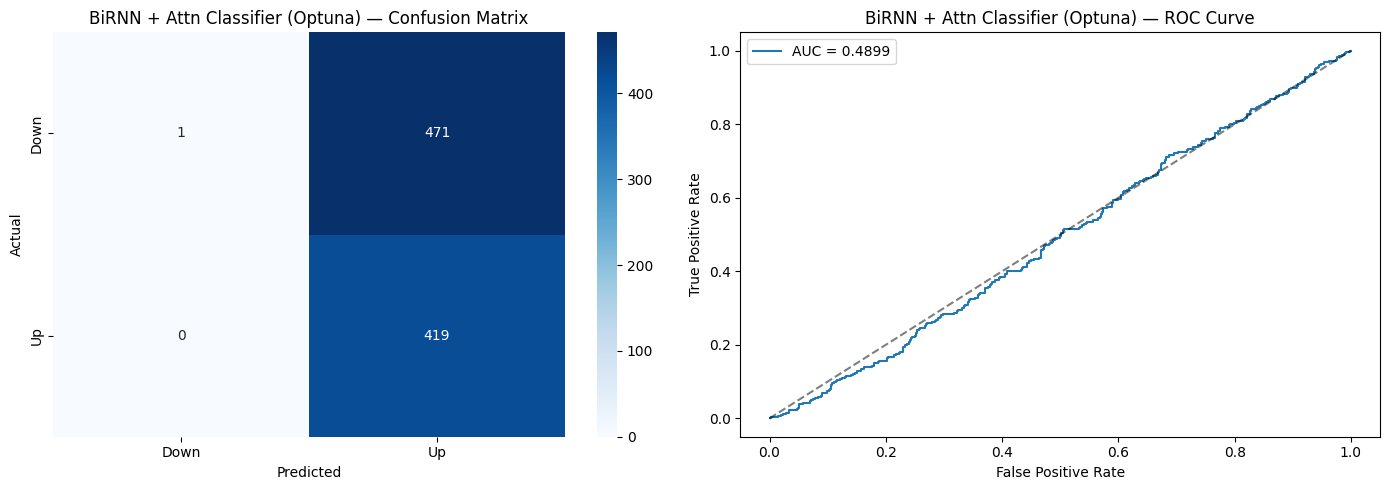


Classification Report (Optuna):
              precision    recall  f1-score   support

        Down       1.00      0.00      0.00       472
          Up       0.47      1.00      0.64       419

    accuracy                           0.47       891
   macro avg       0.74      0.50      0.32       891
weighted avg       0.75      0.47      0.30       891



In [33]:
test_probs_optuna = optuna_cls_model.predict(X_test_cls)
test_preds_optuna = (test_probs_optuna >= best_threshold_optuna).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_opt = confusion_matrix(y_test_cls, test_preds_optuna)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('BiRNN + Attn Classifier (Optuna) — Confusion Matrix')

fpr_opt, tpr_opt, _ = roc_curve(y_test_cls, test_probs_optuna)
axes[1].plot(fpr_opt, tpr_opt, label=f'AUC = {optuna_cls_test["auc_roc"]:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('BiRNN + Attn Classifier (Optuna) — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nClassification Report (Optuna):")
print(classification_report(y_test_cls, test_preds_optuna, target_names=['Down', 'Up']))

### Naive baseline (always predict majority class)

In [34]:
majority_class = int(y_train_cls.mean() >= 0.5)
naive_preds = np.full_like(y_test_cls, majority_class)
naive_acc = accuracy_score(y_test_cls, naive_preds)
naive_f1 = f1_score(y_test_cls, naive_preds, zero_division=0)

print(f"Naive baseline (always predict {'Up' if majority_class else 'Down'}):")
print(f'  Accuracy: {naive_acc:.6f}')
print(f'  F1      : {naive_f1:.6f}')

Naive baseline (always predict Down):
  Accuracy: 0.529742
  F1      : 0.000000


## Classification Model Comparison

In [35]:
cls_comparison = pd.DataFrame([
    {
        'Model': 'Naive (majority)',
        'Accuracy': naive_acc,
        'F1': naive_f1,
        'AUC-ROC': 0.5,
    },
    {
        'Model': 'BiRNN + Attn CLS (Default CV)',
        'Accuracy': default_cls_cv_metrics.get('accuracy', None),
        'F1': default_cls_cv_metrics.get('f1', None),
        'AUC-ROC': default_cls_cv_metrics.get('auc_roc', None),
    },
    {
        'Model': 'BiRNN + Attn CLS (Default Test)',
        'Accuracy': default_cls_test['accuracy'],
        'F1': default_cls_test['f1'],
        'AUC-ROC': default_cls_test['auc_roc'],
    },
    {
        'Model': 'BiRNN + Attn CLS (Optuna CV)',
        'Accuracy': optuna_cls_cv_metrics.get('accuracy', None),
        'F1': optuna_cls_cv_metrics.get('f1', None),
        'AUC-ROC': optuna_cls_cv_metrics.get('auc_roc', None),
    },
    {
        'Model': 'BiRNN + Attn CLS (Optuna Test)',
        'Accuracy': optuna_cls_test['accuracy'],
        'F1': optuna_cls_test['f1'],
        'AUC-ROC': optuna_cls_test['auc_roc'],
    },
])
cls_comparison.style.format(precision=6).highlight_max(
    subset=['Accuracy', 'F1', 'AUC-ROC'], color='lightgreen'
)

,Model,Accuracy,F1,AUC-ROC
0,Naive (majority),0.529742,0.000000,0.500000
1,BiRNN + Attn CLS (Default CV),0.480808,0.646630,0.525680
2,BiRNN + Attn CLS (Default Test),0.470258,0.639695,0.515109
3,BiRNN + Attn CLS (Optuna CV),0.486532,0.647593,0.538497
4,BiRNN + Attn CLS (Optuna Test),0.471380,0.640183,0.489912


### Combined ROC Curves — Default vs Optuna

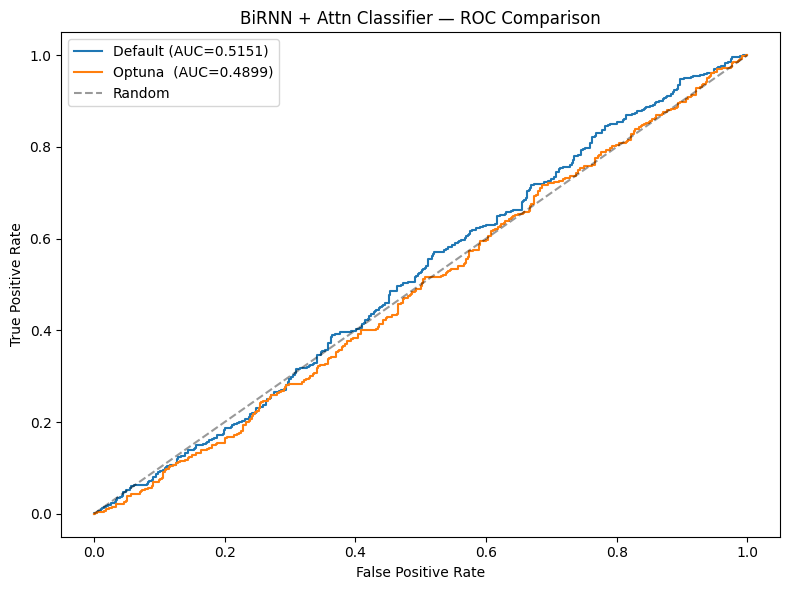

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

fpr_d, tpr_d, _ = roc_curve(y_test_cls, test_probs_default)
fpr_o, tpr_o, _ = roc_curve(y_test_cls, test_probs_optuna)

ax.plot(fpr_d, tpr_d, label=f'Default (AUC={default_cls_test["auc_roc"]:.4f})')
ax.plot(fpr_o, tpr_o, label=f'Optuna  (AUC={optuna_cls_test["auc_roc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('BiRNN + Attn Classifier — ROC Comparison')
ax.legend()
plt.tight_layout()
plt.show()

### Economic Gain Evaluation

Simulate a simple trading strategy: go **long** when the model predicts Up,
**stay flat** (or go short) when it predicts Down. Compare cumulative returns
against a buy-and-hold baseline.

This measures the real-world monetary value of the classifier's predictions.

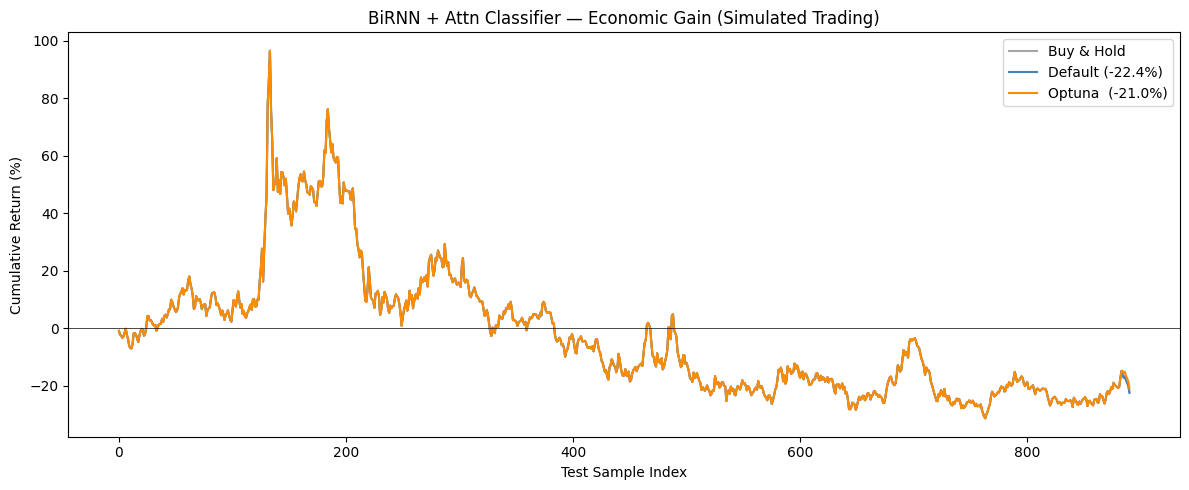

Buy & Hold cumulative return: -22.44%
Default model  cum. return:   -22.44%
Optuna  model  cum. return:   -21.00%


In [37]:
# Actual daily returns for the test period
test_returns = X_test_cls[:, -1, price_col_idx]

# Strategy returns: invest when model predicts Up (1), else 0
strategy_default = test_preds_default * test_returns
strategy_optuna  = test_preds_optuna  * test_returns
buy_hold         = test_returns

cum_default  = np.cumprod(1 + strategy_default) - 1
cum_optuna   = np.cumprod(1 + strategy_optuna)  - 1
cum_buyhold  = np.cumprod(1 + buy_hold)          - 1

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_buyhold * 100,  label='Buy & Hold', color='gray', alpha=0.7)
ax.plot(cum_default * 100,  label=f'Default ({cum_default[-1]*100:.1f}%)', color='steelblue')
ax.plot(cum_optuna  * 100,  label=f'Optuna  ({cum_optuna[-1]*100:.1f}%)', color='darkorange')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('BiRNN + Attn Classifier — Economic Gain (Simulated Trading)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Buy & Hold cumulative return: {cum_buyhold[-1]*100:+.2f}%')
print(f'Default model  cum. return:   {cum_default[-1]*100:+.2f}%')
print(f'Optuna  model  cum. return:   {cum_optuna[-1]*100:+.2f}%')

## Save & Load — Classification

In [ ]:
optuna_cls_model.save('birnn_attention_wheat_cls')

loaded_cls = BiRNNAttentionClassifier()
loaded_cls.load('birnn_attention_wheat_cls')

loaded_cls_metrics = loaded_cls.evaluate(X_test_cls, y_test_cls, threshold=best_threshold_optuna)
print('\nLoaded classifier test metrics:')
for name, value in loaded_cls_metrics.items():
    print(f'  {name.upper()}: {value:.6f}')

print(f"\nProbabilities match: {np.allclose(optuna_cls_model.predict(X_test_cls), loaded_cls.predict(X_test_cls))}")